In [1]:
import mix_utils
import utils

import numpy as np
import torch
import torchvision
import PIL
import matplotlib.pyplot as plt


In [2]:
# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [3]:

BATCH_SIZE = 100
NUM_WORKERS = 8

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

base_trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)


Files already downloaded and verified
Files already downloaded and verified


In [4]:

testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


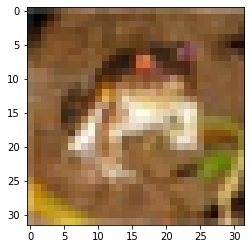

In [5]:
imgs_sample = base_trainset.data[:500]
imgs_sample = np.float32(imgs_sample/255.)
imgs_sample = imgs_sample.transpose((0, 3, 1, 2))

labels_sample = base_trainset.targets[:500]
#print(imgs_sample.shape, imgs_sample[0])
utils.show_np_arr(imgs_sample[0])

In [10]:

indices = mix_utils.buckets_intraclass(labels_sample, 3, 50)
print(indices.shape, indices[:, 0],
      base_trainset.classes[labels_sample[indices[0, 0]]],
      base_trainset.classes[labels_sample[indices[1, 0]]])
ingredients = imgs_sample[indices]
ingredients.shape

(3, 50) [283 303  13] bird bird


(3, 50, 3, 32, 32)

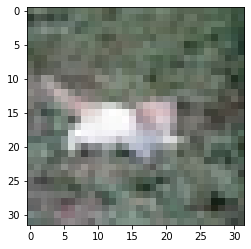

In [7]:
utils.show_np_arr(ingredients[0, 0])

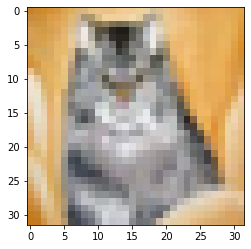

In [8]:
utils.show_np_arr(ingredients[1, 0])

In [49]:
class IntraclassMix(torch.utils.data.Dataset):

    def __init__(self, base_set, lambda_vec, *, sample_size=None, transform=None):
        print("b")
        self.transform = transform        
        
        lam_ = lambda_vec

        N = lam_.shape[0]
        L = sample_size if sample_size else base_set.data.shape[0]
        imgs = np.array(base_set.data[:L])
        
        print("c")
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        
        print("d")
        labels = np.array(base_set.targets[:L])

        print("e")
        self.indices = mix_utils.buckets_intraclass(labels, N, L)
        self.ingredients = imgs[self.indices]

        print("f")
        lam_mask = np.concatenate([
            lam_[i] * np.ones((1, *imgs.shape))
            for i in range(lam_.shape[0])], axis=0)

        print("g")
        self.mixed = (lam_mask * self.ingredients).sum(axis=0)
        self.labels = labels[self.indices[0]]
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        img = self.mixed[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, target


In [55]:

import exp_models

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

model_getter = lambda: exp_models.resnet18(n=100)
    
print_ = utils.get_print(True, fname="delete")

lambdas = [np.array([0.75, 0.25]), np.array([0.5, 0.5])]

for lambda_ in lambdas:
    print_("Trying lambda=", lambda_)
    
    trainset = IntraclassMix(base_trainset,                             
                             lambda_,
                             sample_size=50000,
                             transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


    device = torch.device('cuda' if USE_CUDA else 'cpu')
    model = model_getter().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
    lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

    NMIX = lam_rs_tensor.shape[0]
    print_("Performing n-mixup with N-mix:", NMIX)
    
    for epoch in range(1, N_EPOCHS + 1):
        # Training on all batches
        print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
        for batch_id, (images, labels) in enumerate(trainloader):
            if N_BATCHES and batch_id > N_BATCHES:
                break
            labels, images = labels.to(device), images.to(device)
            #images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images.float(), labels, lam_rs_tensor, device)
            outputs = model(images.float())
            # intraclass
            ys = [labels for _ in range(NMIX)]
            loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
            loss_value = loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses[str(lambda_)].append(loss_value)
            if batch_id % 50 == 0:
                print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                    loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))

        # Validating on one batch
        for images, labels in testloader:
            correct = 0
            total = 0
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            val_acc = 100 * correct / total
            loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
            loss_value = loss.item()

            print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                    loss_value, epoch, N_EPOCHS))
            print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                    val_acc, epoch, N_EPOCHS))
            val_losses[str(lambda_)].append(loss_value)



Trying lambda= [0.75 0.25]
b
c
d
e
f
g
Performing n-mixup with N-mix: 2
Epoch[1/100]


NameError: name 'train_losses' is not defined

In [ ]:


# Test mode
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    # Output test accuracy
    test_acc = 100 * correct / total
    print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
    test_accs[str(lambda_)] = test_acc

## Training on intraclass

In [6]:

import exp_models

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

model_getter = lambda: exp_models.resnet18(n=100)


def perform_experiment(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    val_losses = {str(k):[] for k in lambdas}
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

        NMIX = lam_rs_tensor.shape[0]
        print_("Performing n-mixup with N-mix:", NMIX)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device)
                images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images.float(), labels, lam_rs_tensor, device)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(lambda_)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(lambda_)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(lambda_)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, val_losses, images_mx, ys


In [14]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8


LAMBDAS = [np.array([.75, .25]), np.array([.5, .5])]

for n in range(2):
    RESULTS_FNAME = "results_intraclass100_n2_"+str(n)
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)


saving results in results_intraclass100_n2_0
Trying lambda= [0.75 0.25]
Performing n-mixup with N-mix: 2
Epoch[1/100]
train loss:4.8046 Epoch[1/100] Batch[0/500]
train loss:4.0940 Epoch[1/100] Batch[50/500]
train loss:3.7721 Epoch[1/100] Batch[100/500]
train loss:3.8714 Epoch[1/100] Batch[150/500]
train loss:3.5691 Epoch[1/100] Batch[200/500]
train loss:3.8250 Epoch[1/100] Batch[250/500]
train loss:3.5985 Epoch[1/100] Batch[300/500]
train loss:3.6103 Epoch[1/100] Batch[350/500]
train loss:3.5259 Epoch[1/100] Batch[400/500]
train loss:3.3412 Epoch[1/100] Batch[450/500]
val loss:5.8272 Epoch[1/100]
val acc:19.0000 Epoch[1/100]
Epoch[2/100]
train loss:3.4945 Epoch[2/100] Batch[0/500]
train loss:3.2141 Epoch[2/100] Batch[50/500]
train loss:3.1800 Epoch[2/100] Batch[100/500]
train loss:3.1695 Epoch[2/100] Batch[150/500]
train loss:3.0536 Epoch[2/100] Batch[200/500]
train loss:2.9116 Epoch[2/100] Batch[250/500]
train loss:2.7854 Epoch[2/100] Batch[300/500]
train loss:2.9373 Epoch[2/100] Batc

Traceback (most recent call last):
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/util.py", line 265, in _run_finalizers
    finalizer()
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/util.py", line 189, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/data/landelle/anaconda3/lib/python3.7/shutil.py", line 495, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/data/landelle/anaconda3/lib/python3.7/shutil.py", line 493, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-vumk7s5u'


val loss:6.1080 Epoch[11/100]
val acc:44.0000 Epoch[11/100]
Epoch[12/100]
train loss:1.6513 Epoch[12/100] Batch[0/500]
train loss:1.8432 Epoch[12/100] Batch[50/500]
train loss:1.8049 Epoch[12/100] Batch[100/500]
train loss:1.7985 Epoch[12/100] Batch[150/500]
train loss:1.7273 Epoch[12/100] Batch[200/500]
train loss:1.7141 Epoch[12/100] Batch[250/500]
train loss:1.7427 Epoch[12/100] Batch[300/500]
train loss:1.7388 Epoch[12/100] Batch[350/500]
train loss:1.7493 Epoch[12/100] Batch[400/500]
train loss:1.8211 Epoch[12/100] Batch[450/500]
val loss:6.2889 Epoch[12/100]
val acc:47.0000 Epoch[12/100]
Epoch[13/100]
train loss:1.7657 Epoch[13/100] Batch[0/500]
train loss:1.7431 Epoch[13/100] Batch[50/500]
train loss:1.6954 Epoch[13/100] Batch[100/500]
train loss:1.7423 Epoch[13/100] Batch[150/500]
train loss:1.6744 Epoch[13/100] Batch[200/500]
train loss:1.7172 Epoch[13/100] Batch[250/500]
train loss:1.7563 Epoch[13/100] Batch[300/500]
train loss:1.7916 Epoch[13/100] Batch[350/500]
train loss:1

train loss:1.5156 Epoch[27/100] Batch[50/500]
train loss:1.5292 Epoch[27/100] Batch[100/500]
train loss:1.5146 Epoch[27/100] Batch[150/500]
train loss:1.5366 Epoch[27/100] Batch[200/500]
train loss:1.5530 Epoch[27/100] Batch[250/500]
train loss:1.4967 Epoch[27/100] Batch[300/500]
train loss:1.5666 Epoch[27/100] Batch[350/500]
train loss:1.5490 Epoch[27/100] Batch[400/500]
train loss:1.5534 Epoch[27/100] Batch[450/500]
val loss:6.9526 Epoch[27/100]
val acc:39.0000 Epoch[27/100]
Epoch[28/100]
train loss:1.4423 Epoch[28/100] Batch[0/500]
train loss:1.4328 Epoch[28/100] Batch[50/500]
train loss:1.5575 Epoch[28/100] Batch[100/500]
train loss:1.4782 Epoch[28/100] Batch[150/500]
train loss:1.5275 Epoch[28/100] Batch[200/500]
train loss:1.4559 Epoch[28/100] Batch[250/500]
train loss:1.5208 Epoch[28/100] Batch[300/500]
train loss:1.5172 Epoch[28/100] Batch[350/500]
train loss:1.4894 Epoch[28/100] Batch[400/500]
train loss:1.5317 Epoch[28/100] Batch[450/500]
val loss:6.7178 Epoch[28/100]
val acc

train loss:1.3890 Epoch[42/100] Batch[150/500]
train loss:1.3633 Epoch[42/100] Batch[200/500]
train loss:1.4069 Epoch[42/100] Batch[250/500]
train loss:1.3842 Epoch[42/100] Batch[300/500]
train loss:1.4471 Epoch[42/100] Batch[350/500]
train loss:1.4251 Epoch[42/100] Batch[400/500]
train loss:1.4142 Epoch[42/100] Batch[450/500]
val loss:6.9494 Epoch[42/100]
val acc:31.0000 Epoch[42/100]
Epoch[43/100]
train loss:1.3160 Epoch[43/100] Batch[0/500]
train loss:1.4224 Epoch[43/100] Batch[50/500]
train loss:1.3903 Epoch[43/100] Batch[100/500]
train loss:1.4091 Epoch[43/100] Batch[150/500]
train loss:1.4120 Epoch[43/100] Batch[200/500]
train loss:1.3754 Epoch[43/100] Batch[250/500]
train loss:1.4074 Epoch[43/100] Batch[300/500]
train loss:1.3823 Epoch[43/100] Batch[350/500]
train loss:1.4112 Epoch[43/100] Batch[400/500]
train loss:1.4717 Epoch[43/100] Batch[450/500]
val loss:7.3521 Epoch[43/100]
val acc:36.0000 Epoch[43/100]
Epoch[44/100]
train loss:1.3679 Epoch[44/100] Batch[0/500]
train loss:

...

train loss:1.5020 Epoch[30/100] Batch[250/500]
train loss:1.4012 Epoch[30/100] Batch[300/500]
train loss:1.5136 Epoch[30/100] Batch[350/500]
train loss:1.3981 Epoch[30/100] Batch[400/500]
train loss:1.4086 Epoch[30/100] Batch[450/500]
val loss:9.8133 Epoch[30/100]
val acc:32.0000 Epoch[30/100]
Epoch[31/100]
train loss:1.3400 Epoch[31/100] Batch[0/500]
train loss:1.4558 Epoch[31/100] Batch[50/500]
train loss:1.4892 Epoch[31/100] Batch[100/500]
train loss:1.3806 Epoch[31/100] Batch[150/500]
train loss:1.4253 Epoch[31/100] Batch[200/500]
train loss:1.4178 Epoch[31/100] Batch[250/500]
train loss:1.4351 Epoch[31/100] Batch[300/500]
train loss:1.3660 Epoch[31/100] Batch[350/500]
train loss:1.4362 Epoch[31/100] Batch[400/500]
train loss:1.4555 Epoch[31/100] Batch[450/500]
val loss:10.2271 Epoch[31/100]
val acc:39.0000 Epoch[31/100]
Epoch[32/100]
train loss:1.2957 Epoch[32/100] Batch[0/500]
train loss:1.4209 Epoch[32/100] Batch[50/500]
train loss:1.5863 Epoch[32/100] Batch[100/500]
train loss:

train loss:1.2065 Epoch[45/100] Batch[350/500]
train loss:1.1240 Epoch[45/100] Batch[400/500]
train loss:1.2210 Epoch[45/100] Batch[450/500]
val loss:11.0568 Epoch[45/100]
val acc:37.0000 Epoch[45/100]
Epoch[46/100]
train loss:1.2920 Epoch[46/100] Batch[0/500]
train loss:1.1810 Epoch[46/100] Batch[50/500]
train loss:1.2333 Epoch[46/100] Batch[100/500]
train loss:1.2385 Epoch[46/100] Batch[150/500]
train loss:1.1448 Epoch[46/100] Batch[200/500]
train loss:1.2426 Epoch[46/100] Batch[250/500]
train loss:1.1691 Epoch[46/100] Batch[300/500]
train loss:1.2145 Epoch[46/100] Batch[350/500]
train loss:1.1674 Epoch[46/100] Batch[400/500]
train loss:1.2110 Epoch[46/100] Batch[450/500]
val loss:11.0392 Epoch[46/100]
val acc:32.0000 Epoch[46/100]
Epoch[47/100]
train loss:1.1442 Epoch[47/100] Batch[0/500]
train loss:1.1923 Epoch[47/100] Batch[50/500]
train loss:1.2044 Epoch[47/100] Batch[100/500]
train loss:1.2489 Epoch[47/100] Batch[150/500]
train loss:1.1692 Epoch[47/100] Batch[200/500]
train loss

train loss:1.0571 Epoch[60/100] Batch[450/500]
val loss:11.9409 Epoch[60/100]
val acc:38.0000 Epoch[60/100]
Epoch[61/100]
train loss:0.9959 Epoch[61/100] Batch[0/500]
train loss:0.9869 Epoch[61/100] Batch[50/500]
train loss:1.1063 Epoch[61/100] Batch[100/500]
train loss:1.0288 Epoch[61/100] Batch[150/500]
train loss:0.9816 Epoch[61/100] Batch[200/500]
train loss:1.0898 Epoch[61/100] Batch[250/500]
train loss:0.9905 Epoch[61/100] Batch[300/500]
train loss:1.0369 Epoch[61/100] Batch[350/500]
train loss:1.0666 Epoch[61/100] Batch[400/500]
train loss:0.9943 Epoch[61/100] Batch[450/500]
val loss:12.0177 Epoch[61/100]
val acc:35.0000 Epoch[61/100]
Epoch[62/100]
train loss:1.0487 Epoch[62/100] Batch[0/500]
train loss:0.9954 Epoch[62/100] Batch[50/500]
train loss:1.0927 Epoch[62/100] Batch[100/500]
train loss:1.1063 Epoch[62/100] Batch[150/500]
train loss:1.0825 Epoch[62/100] Batch[200/500]
train loss:1.0711 Epoch[62/100] Batch[250/500]
train loss:1.0721 Epoch[62/100] Batch[300/500]
train loss

train loss:1.0520 Epoch[76/100] Batch[0/500]
train loss:0.9037 Epoch[76/100] Batch[50/500]
train loss:1.0409 Epoch[76/100] Batch[100/500]
train loss:0.9236 Epoch[76/100] Batch[150/500]
train loss:0.9223 Epoch[76/100] Batch[200/500]
train loss:0.9066 Epoch[76/100] Batch[250/500]
train loss:0.9868 Epoch[76/100] Batch[300/500]
train loss:0.9067 Epoch[76/100] Batch[350/500]
train loss:0.9524 Epoch[76/100] Batch[400/500]
train loss:0.9612 Epoch[76/100] Batch[450/500]
val loss:13.2647 Epoch[76/100]
val acc:31.0000 Epoch[76/100]
Epoch[77/100]
train loss:1.0048 Epoch[77/100] Batch[0/500]
train loss:0.8819 Epoch[77/100] Batch[50/500]
train loss:1.0152 Epoch[77/100] Batch[100/500]
train loss:1.0056 Epoch[77/100] Batch[150/500]
train loss:0.9680 Epoch[77/100] Batch[200/500]
train loss:0.9343 Epoch[77/100] Batch[250/500]
train loss:0.9808 Epoch[77/100] Batch[300/500]
train loss:0.9144 Epoch[77/100] Batch[350/500]
train loss:0.9216 Epoch[77/100] Batch[400/500]
train loss:0.9815 Epoch[77/100] Batch[

train loss:0.9603 Epoch[91/100] Batch[100/500]
train loss:0.8716 Epoch[91/100] Batch[150/500]
train loss:0.9428 Epoch[91/100] Batch[200/500]
train loss:0.9281 Epoch[91/100] Batch[250/500]
train loss:0.9457 Epoch[91/100] Batch[300/500]
train loss:0.8976 Epoch[91/100] Batch[350/500]
train loss:0.9055 Epoch[91/100] Batch[400/500]
train loss:0.9086 Epoch[91/100] Batch[450/500]
val loss:13.5993 Epoch[91/100]
val acc:36.0000 Epoch[91/100]
Epoch[92/100]
train loss:0.8504 Epoch[92/100] Batch[0/500]
train loss:0.8873 Epoch[92/100] Batch[50/500]
train loss:0.8696 Epoch[92/100] Batch[100/500]
train loss:0.9105 Epoch[92/100] Batch[150/500]
train loss:0.9341 Epoch[92/100] Batch[200/500]
train loss:0.9134 Epoch[92/100] Batch[250/500]
train loss:0.9248 Epoch[92/100] Batch[300/500]
train loss:0.8633 Epoch[92/100] Batch[350/500]
train loss:0.9181 Epoch[92/100] Batch[400/500]
train loss:0.9576 Epoch[92/100] Batch[450/500]
val loss:14.0467 Epoch[92/100]
val acc:32.0000 Epoch[92/100]
Epoch[93/100]
train l

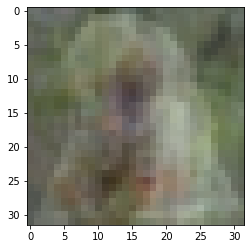

In [52]:
utils.show_np_arr(images_mx[0].cpu())

In [7]:
class InterclassMix(torch.utils.data.Dataset):

    def __init__(self, base_set, lambda_vec, *, sample_size=None, transform=None):
        print("b")
        self.transform = transform        
        
        lam_ = lambda_vec

        N = lam_.shape[0]
        L = sample_size if sample_size else base_set.data.shape[0]
        imgs = np.array(base_set.data[:L])
        
        print("c")
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        
        print("d")
        labels = np.array(base_set.targets[:L])

        print("e")
        indices = mix_utils.buckets_interclass(labels, N, L)
        ingredients = imgs[indices]

        print("f")
        lam_mask = np.concatenate([
            lam_[i] * np.ones((1, *imgs.shape))
            for i in range(lam_.shape[0])], axis=0)

        print("g")
        self.mixed = (lam_mask * ingredients).sum(axis=0)
        self.labels = labels[indices[0]]
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        img = self.mixed[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, target

print("a")


trainset = InterclassMix(base_trainset,
                                lam_,
                                sample_size=50000,
                                transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

for imgs, targets in trainloader:
    print("class:", base_trainset.classes[targets[0]])
    show_np_array(imgs[0])
    break

a


NameError: name 'lam_' is not defined

In [ ]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8


LAMBDAS = [np.array([.75, .25]), np.array([.5, .5])]

for n in range(2):
    RESULTS_FNAME = "results_intraclass100_n2_"+str(n)
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)